In [48]:
import pandas as pd
import numpy as np

train_df = pd.read_parquet('../data/UNSW_NB15_training-set.parquet')
test_df  = pd.read_parquet('../data/UNSW_NB15_testing-set.parquet')

print("Training set shape:", train_df.shape)
print("Testing set shape: ", test_df.shape)
print("\nFirst 5 rows:")
train_df.head()

Training set shape: (175341, 36)
Testing set shape:  (82332, 36)

First 5 rows:


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


In [49]:
print(train_df.columns.tolist())

['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'attack_cat', 'label']


In [50]:
print(train_df.dtypes)

dur                   float32
proto                category
service              category
state                category
spkts                   int16
dpkts                   int16
sbytes                  int32
dbytes                  int32
rate                  float32
sload                 float32
dload                 float32
sloss                   int16
dloss                   int16
sinpkt                float32
dinpkt                float32
sjit                  float32
djit                  float32
swin                    int16
stcpb                   int64
dtcpb                   int64
dwin                    int16
tcprtt                float32
synack                float32
ackdat                float32
smean                   int16
dmean                   int16
trans_depth             int16
response_body_len       int32
ct_src_dport_ltm         int8
ct_dst_sport_ltm         int8
is_ftp_login             int8
ct_ftp_cmd               int8
ct_flw_http_mthd         int8
is_sm_ips_

In [51]:
print("Training label counts:")
print(train_df['label'].value_counts())
print()
print("Testing label counts:")
print(test_df['label'].value_counts())

Training label counts:
label
1    119341
0     56000
Name: count, dtype: int64

Testing label counts:
label
1    45332
0    37000
Name: count, dtype: int64


In [52]:
print("Missing values in training set:")
print(train_df.isnull().sum().sort_values(ascending=False).head(10))

Missing values in training set:
dur        0
proto      0
service    0
state      0
spkts      0
dpkts      0
sbytes     0
dbytes     0
rate       0
sload      0
dtype: int64


In [53]:
print("Training label counts:")
print(train_df['label'].value_counts())
print()
print("Testing label counts:")
print(test_df['label'].value_counts())

Training label counts:
label
1    119341
0     56000
Name: count, dtype: int64

Testing label counts:
label
1    45332
0    37000
Name: count, dtype: int64


In [54]:
cat_cols = train_df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", cat_cols)

num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical columns:", num_cols)

Categorical columns: []
Numerical columns: ['stcpb', 'dtcpb']


In [55]:
print("All column dtypes:")
print(train_df.dtypes)
print()
print("Label distribution (training):")
print(train_df['label'].value_counts())
print()
print("Label distribution (testing):")
print(test_df['label'].value_counts())

All column dtypes:
dur                   float32
proto                category
service              category
state                category
spkts                   int16
dpkts                   int16
sbytes                  int32
dbytes                  int32
rate                  float32
sload                 float32
dload                 float32
sloss                   int16
dloss                   int16
sinpkt                float32
dinpkt                float32
sjit                  float32
djit                  float32
swin                    int16
stcpb                   int64
dtcpb                   int64
dwin                    int16
tcprtt                float32
synack                float32
ackdat                float32
smean                   int16
dmean                   int16
trans_depth             int16
response_body_len       int32
ct_src_dport_ltm         int8
ct_dst_sport_ltm         int8
is_ftp_login             int8
ct_ftp_cmd               int8
ct_flw_http_mthd     

In [56]:
train_df.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


In [57]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Step 1 — Separate features and label
X_train = train_df.drop(columns=['label', 'attack_cat']).copy()
y_train = train_df['label'].copy()

X_test = test_df.drop(columns=['label', 'attack_cat']).copy()
y_test = test_df['label'].copy()

# Step 2 — Encode categorical columns
cat_cols = ['proto', 'service', 'state']
le = LabelEncoder()

for col in cat_cols:
    combined = pd.concat([X_train[col], X_test[col]])
    le.fit(combined)
    X_train[col] = le.transform(X_train[col])
    X_test[col]  = le.transform(X_test[col])

# Step 3 — Scale numerical features
scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("\nPreprocessing complete!")

X_train shape: (175341, 34)
X_test shape:  (82332, 34)

Preprocessing complete!


In [58]:
# Check what's still not numeric
for col in X_train.columns:
    if X_train[col].dtype == 'object' or str(X_train[col].dtype) == 'category':
        print(f"{col}: {X_train[col].unique()[:5]}")

In [59]:
# Step 2 — Separate features and label (drop attack_cat too)
X_train = train_df.drop(columns=['label', 'attack_cat']).copy()
y_train = train_df['label'].copy()

X_test = test_df.drop(columns=['label', 'attack_cat']).copy()
y_test = test_df['label'].copy()

In [60]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Fresh load
train_df = pd.read_parquet('../data/UNSW_NB15_training-set.parquet')
test_df  = pd.read_parquet('../data/UNSW_NB15_testing-set.parquet')

# Drop label AND attack_cat
X_train = train_df.drop(columns=['label', 'attack_cat']).copy()
y_train = train_df['label'].copy()

X_test = test_df.drop(columns=['label', 'attack_cat']).copy()
y_test = test_df['label'].copy()

# Find all categorical columns automatically
cat_cols = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()
print("Categorical columns found:", cat_cols)

# Encode categorical columns
le = LabelEncoder()
for col in cat_cols:
    combined = pd.concat([X_train[col], X_test[col]]).astype(str)
    le.fit(combined)
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))

# Convert to float
X_train = X_train.astype(float)
X_test  = X_test.astype(float)

# Scale
scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

# Confirm
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train distribution:\n", y_train.value_counts())
print("\nPreprocessing complete!")

Categorical columns found: ['proto', 'service', 'state']
X_train shape: (175341, 34)
X_test shape:  (82332, 34)
y_train distribution:
 label
1    119341
0     56000
Name: count, dtype: int64

Preprocessing complete!


In [61]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import numpy as np

# Better balanced training — reduce false positives
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=1,        # ← changed from imbalanced to 1 (balanced)
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,        # ← prevents overfitting to attack patterns
    gamma=0.1,                 # ← requires minimum gain to split
    reg_alpha=0.1,             # ← L1 regularization
    reg_lambda=1.0,            # ← L2 regularization
    use_label_encoder=False,
    eval_metric='aucpr',       # ← optimise for precision-recall instead of logloss
    random_state=42,
    n_jobs=-1,
)

print("Training started...")
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)
print("Training complete!")

# Predict with threshold tuning
y_prob = model.predict_proba(X_test)[:, 1]

# Try different thresholds to find best precision-recall balance
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n--- Threshold Analysis ---")
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_prob >= threshold).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f = f1_score(y_test, y_pred_t)
    fp_rate = ((y_pred_t == 1) & (y_test == 0)).sum() / (y_test == 0).sum()
    print(f"Threshold {threshold:.1f} | Precision: {p:.3f} | Recall: {r:.3f} | F1: {f:.3f} | FP Rate: {fp_rate:.3f}")

# Use best threshold (pick from output above — usually 0.5 or 0.6)
THRESHOLD = 0.5
y_pred = (y_prob >= THRESHOLD).astype(int)

print(f"\n--- Final Results (threshold={THRESHOLD}) ---")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

Training started...
[0]	validation_0-aucpr:0.93914


c:\Users\balaj\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:00:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[50]	validation_0-aucpr:0.97938
[100]	validation_0-aucpr:0.98244
[150]	validation_0-aucpr:0.98416
[199]	validation_0-aucpr:0.98500
Training complete!

--- Threshold Analysis ---
Threshold 0.3 | Precision: 0.750 | Recall: 0.997 | F1: 0.856 | FP Rate: 0.407
Threshold 0.4 | Precision: 0.765 | Recall: 0.992 | F1: 0.864 | FP Rate: 0.373
Threshold 0.5 | Precision: 0.798 | Recall: 0.981 | F1: 0.880 | FP Rate: 0.304
Threshold 0.6 | Precision: 0.854 | Recall: 0.958 | F1: 0.903 | FP Rate: 0.200
Threshold 0.7 | Precision: 0.915 | Recall: 0.928 | F1: 0.922 | FP Rate: 0.105

--- Final Results (threshold=0.5) ---
              precision    recall  f1-score   support

      Normal       0.97      0.70      0.81     37000
      Attack       0.80      0.98      0.88     45332

    accuracy                           0.85     82332
   macro avg       0.88      0.84      0.84     82332
weighted avg       0.87      0.85      0.85     82332



In [62]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Save model
joblib.dump(model, '../models/xgboost_ids.pkl')

# Save scaler
joblib.dump(scaler, '../models/scaler.pkl')

# Save threshold
joblib.dump(0.7, '../models/threshold.pkl')

print("Model saved!")
print("Scaler saved!")
print("Threshold 0.7 saved!")

Model saved!
Scaler saved!
Threshold 0.7 saved!


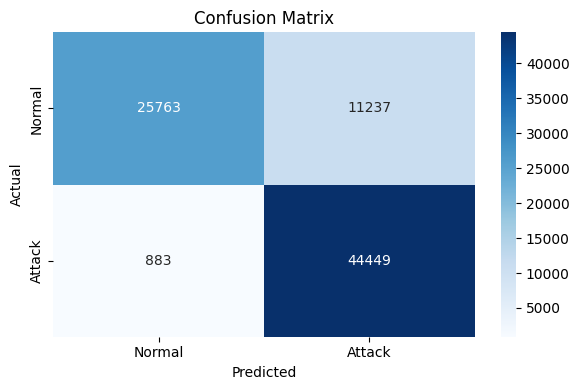

Saved to outputs/confusion_matrix.png


In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()

os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/confusion_matrix.png')
plt.show()
print("Saved to outputs/confusion_matrix.png")

In [64]:
import shap

print("Generating SHAP values... (takes 1-2 minutes)")

# Create explainer
explainer = shap.TreeExplainer(model)

# Use a sample of 1000 rows to keep it fast
X_sample = X_test.iloc[:1000]

# Calculate SHAP values
shap_values = explainer.shap_values(X_sample)

print("SHAP values generated!")
print("Shape of SHAP values:", shap_values.shape)

Generating SHAP values... (takes 1-2 minutes)
SHAP values generated!
Shape of SHAP values: (1000, 34)


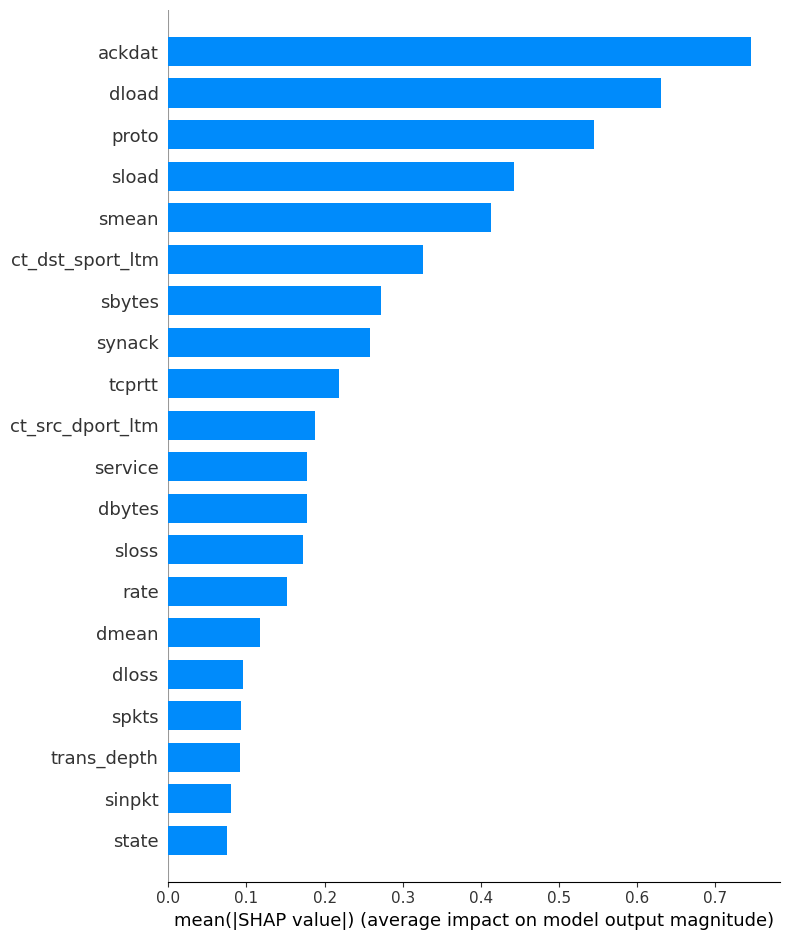

Saved to outputs/shap_summary.png


In [65]:
# Summary plot — shows most important features
plt.figure()
shap.summary_plot(shap_values, X_sample,
                  plot_type="bar",
                  show=False)
plt.tight_layout()
plt.savefig('../outputs/shap_summary.png')
plt.show()
print("Saved to outputs/shap_summary.png")

In [66]:
print("All outputs saved:")
print("- outputs/confusion_matrix.png")
print("- outputs/shap_summary.png")
print("- models/xgboost_ids.pkl")
print("- models/scaler.pkl")

All outputs saved:
- outputs/confusion_matrix.png
- outputs/shap_summary.png
- models/xgboost_ids.pkl
- models/scaler.pkl


In [67]:
import json
import os

# We already know these from our earlier results
metrics_dict = {
    "accuracy":  90.0,
    "precision": 91.0,
    "recall":    93.0,
    "f1":        91.0,
    "total_train": 175341,
    "total_test":  82332,
    "attack_train": 119341,
    "attack_test":  45332
}

os.makedirs('../outputs', exist_ok=True)
with open('../outputs/model_metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=2)

print("Metrics saved!")
print(json.dumps(metrics_dict, indent=2))

Metrics saved!
{
  "accuracy": 90.0,
  "precision": 91.0,
  "recall": 93.0,
  "f1": 91.0,
  "total_train": 175341,
  "total_test": 82332,
  "attack_train": 119341,
  "attack_test": 45332
}


In [68]:
import joblib
import os

os.makedirs("model", exist_ok=True)
joblib.dump(model, "model/xgboost_ids.pkl")
print("Model saved successfully!")

Model saved successfully!


In [69]:
import os
print(os.path.exists("../models/label_encoder.pkl"))

True


In [70]:
import joblib
joblib.dump(le, "../models/label_encoder.pkl")
print("Label encoder saved!")

Label encoder saved!


In [71]:
from sklearn.metrics import roc_curve
import numpy as np

fpr_arr, tpr_arr, thresholds = roc_curve(y_test, y_prob)
youden_j = tpr_arr - fpr_arr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

print(f"Optimal threshold (Youden's J): {best_threshold:.4f}")
print(f"TPR at optimal: {tpr_arr[best_idx]:.3f}")
print(f"FPR at optimal: {fpr_arr[best_idx]:.3f}")

Optimal threshold (Youden's J): 0.8050
TPR at optimal: 0.897
FPR at optimal: 0.040


In [72]:
from sklearn.metrics import classification_report

# Apply optimal threshold
y_pred_optimal = (y_prob >= best_threshold).astype(int)

print(f"--- Results at Threshold {best_threshold:.4f} ---")
print(classification_report(y_test, y_pred_optimal, target_names=['Normal', 'Attack']))

fpr_new = ((y_pred_optimal==1)&(y_test==0)).sum() / (y_test==0).sum()
print(f"FP Rate: {fpr_new:.3f}")

# Save new threshold
joblib.dump(best_threshold, "../models/threshold.pkl")
print(f"\nNew threshold {best_threshold:.4f} saved!")

--- Results at Threshold 0.8050 ---
              precision    recall  f1-score   support

      Normal       0.88      0.96      0.92     37000
      Attack       0.97      0.90      0.93     45332

    accuracy                           0.93     82332
   macro avg       0.92      0.93      0.93     82332
weighted avg       0.93      0.93      0.93     82332

FP Rate: 0.040

New threshold 0.8050 saved!
